# Assignment 2 - Image Inpainting

Name: Ramon Näf <br>
Matriculation number: 20-116-950

In [41]:
from numpy import *
from PIL import Image
import matplotlib.pyplot as plt
from skimage.transform import resize
from tqdm import tqdm
from scipy import sparse
from scipy.signal import convolve2d
import numpy as np
from hessian_matrix import *
from scipy.sparse import triu, tril, diags

## Test Image

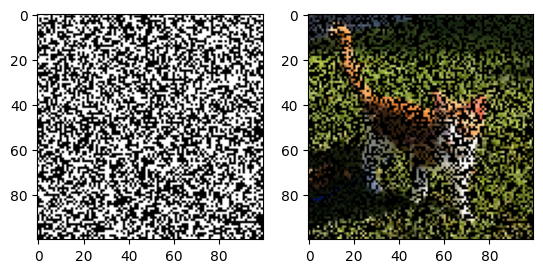

In [42]:
masked_img = np.array(Image.open('masked_cat.png')) / 255
omega = np.array(Image.open('mask.png'))/ 255
g = masked_img

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(omega, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(g)

## hessian_matrix() function

We provide the implementation of the hessian matrix.

input variables: 
- u: your image
- omega: binary mask
- reg: regularization parameter

Example usage:

In [43]:
u_ex = np.zeros(9).reshape(3,3)
reg_lambda = 1
k_type_ex = 3
A = hessian_matrix(u_ex, omega, reg_lambda)
A_n_t = A.toarray()
print(A_n_t)

[[ 4. -2.  0. -2.  0.  0.  0.  0.  0.]
 [-2.  8. -2.  0. -2.  0.  0.  0.  0.]
 [ 0. -2.  6.  0.  0. -2.  0.  0.  0.]
 [-2.  0.  0.  8. -2.  0. -2.  0.  0.]
 [ 0. -2.  0. -2. 10. -2.  0. -2.  0.]
 [ 0.  0. -2.  0. -2.  8.  0.  0. -2.]
 [ 0.  0.  0. -2.  0.  0.  6. -2.  0.]
 [ 0.  0.  0.  0. -2.  0. -2.  6. -2.]
 [ 0.  0.  0.  0.  0. -2.  0. -2.  6.]]


## Implementation


In [44]:
def GD(g, omega, lmbda):
    """
    Gradient Descent algorithm
    g: masked image of size (M, N, 3)
    omega: binary mask of size (M, N)
    lmbda: regularization parameter

    returns: u - inpainted image (M, N, 3)

    """
    u = g.copy() # TODO: replace with actual implementation
    N = g.shape[1]
    M = g.shape[0]
    epsilon = 10 ** (-5)

    it = 0
    max_iter = 100
    criterium = 1

    while (criterium >= epsilon) or it < max_iter:
        
        grad_R = gradient(u[:, :, 0], g[:, :, 0], omega, lmbda, N, M)
        grad_G = gradient(u[:, :, 1], g[:, :, 1], omega, lmbda, N, M)
        grad_B = gradient(u[:, :, 2], g[:, :, 2], omega, lmbda, N, M)

        u[:, :, 0] = u[:, :, 0] - lmbda * grad_R
        u[:, :, 1] = u[:, :, 1] - lmbda * grad_G
        u[:, :, 2] = u[:, :, 2] - lmbda * grad_B

        it = it + 1

        criterium = np.sum(grad_R) + np.sum(grad_G) + np.sum(grad_B)

    return u


def gradient(u, g, omega, lmbda, N, M) :
    grad = np.zeros(u.shape)

    grad[0, 0] = 2 * omega[0, 0] * (u[0, 0] - g[0, 0]) + 2 * lmbda * (u[2, 1] - 2 * u[1, 1] + u[1, 2])
    grad[N-1, M-1] = 2 * omega[N-1, M-1] * (u[N-1, M-1] - g[N-1, M-1])

    for i in range(1, N-2) :
        for j in range(2, M-2) :
            grad[i, j] = 2 * omega[i, j] * (u[i, j] - g[i, j]) + 2 * lmbda * (u[i+1, j] + u[i, j+1] - u[i-1, j] - u[i, j-1])


    return grad


In [45]:
def LGS(g, omega, lmbda):
    """
    Gradient Descent algorithm
    g: masked image of size (M, N, 3)
    omega: binary mask of size (M, N)
    lmbda: regularization parameter

    returns: u - inpainted image (M, N, 3)

    """
    u = g  # TODO: replace with actual implementation
        

    #A_inv = np.linalg.pinv()

    return u

## GRADIENT DESCENT

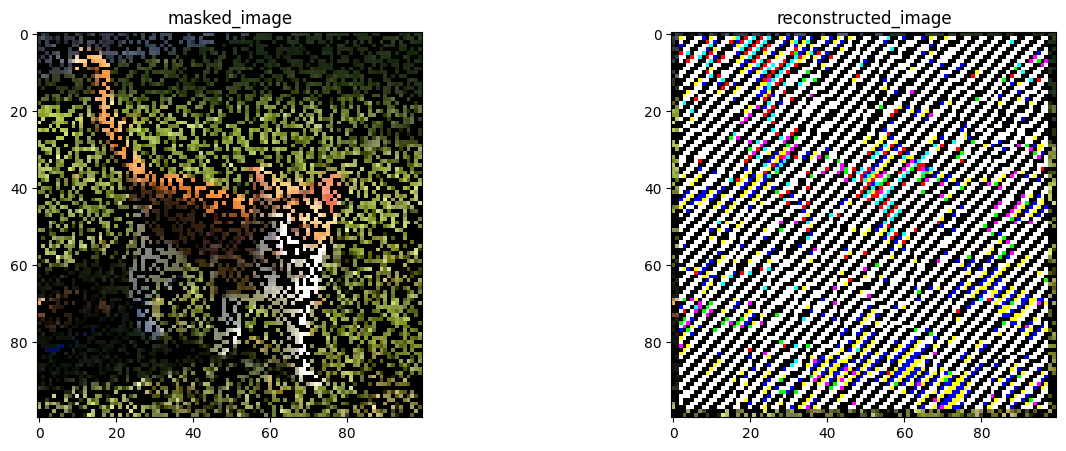

In [46]:
# run gradient descent algorithm
inpainted_img_gd = GD(g, omega, reg_lambda)

# for visualization purpose 
inpainted_img_gd = np.clip(inpainted_img_gd, 0, 1)


plt.figure(figsize=(15, 5))
ax1 = plt.subplot(1, 2, 1)
plt.imshow(masked_img)
ax2 = plt.subplot(1, 2, 2)
plt.imshow(inpainted_img_gd)


ax1.set_title("masked_image")
ax2.set_title("reconstructed_image")
plt.show()

## GAUSS - SEIDEL

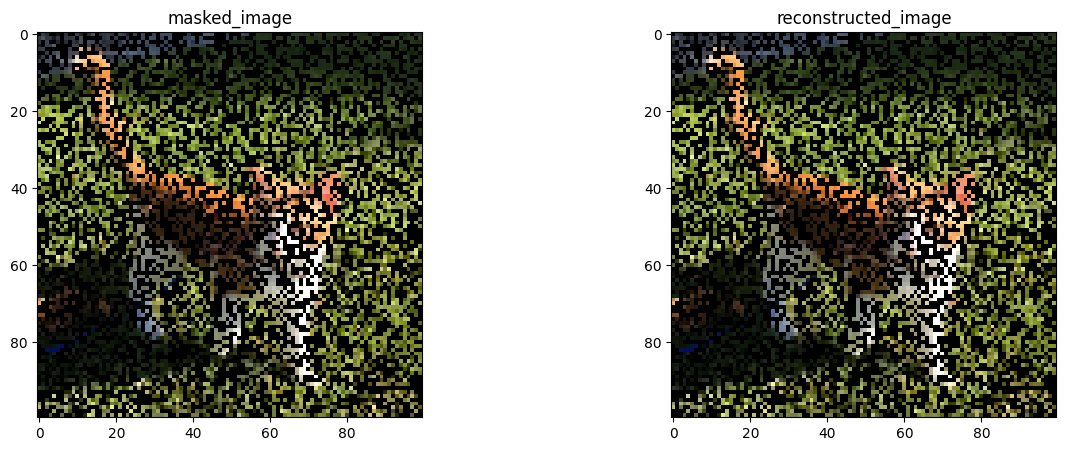

In [47]:
# run gradient descent algorithm
inpainted_img_lgs = LGS(g, omega, reg_lambda)

# for visualization purpose 
inpainted_img_lgs = np.clip(inpainted_img_lgs, 0, 1)


plt.figure(figsize=(15, 5))
ax1 = plt.subplot(1, 2, 1)
plt.imshow(masked_img)
ax2 = plt.subplot(1, 2, 2)
plt.imshow(inpainted_img_lgs)


ax1.set_title("masked_image")
ax2.set_title("reconstructed_image")
plt.show()

### Effect of the regularization parameter lmbda 